# Computer Exercise 14.7 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.7 Incremental SGD / Mini-batch Online Learning — 확률적 경사하강과 학습률 스케줄
> **풀이 일자**: 2026-07-07 (자동 생성)
> **언어**: 본문 한국어 / 그래프 라벨 영문

**주제**: **상수 학습률 SGD** 를 §14.6 의 **망각인자 RLS** 와 대응시킨다 — 상수 $\eta$ 는 유효기억 $N_{\text{eff}}\!\approx\!1/\eta$ 를 만드는 *망각* 기제이며, 같은 드리프트(램프+급점프) 스트림에서 $\eta$ 스윕이 만드는 **U자 추적 상충**을 정량화하고, 두 방법을 best-vs-best 로 비교한다.


## 1. 문제 (원문)

> **3.** Show that **constant step-size SGD** acts as a *forgetting* mechanism analogous to the exponential forgetting factor of recursive least squares (§14.6). Apply constant-$\eta$ SGD to the **same non-stationary stream** used for forgetting-RLS (a slow ramp plus an abrupt jump), sweep $\eta$, and measure the tracking error against the known ground truth. Exhibit the same U-shaped trade-off and relate the step size $\eta$ to an **effective memory length**. Compare the best constant-$\eta$ SGD tracker to forgetting-RLS on the same data.

### 한국어 풀이용 정리
- Day62(§14.6) 와 **동일한** 비정상 스트림: 절편은 완만한 램프, 기울기는 $t=600$ 에서 급점프.
- 상수 $\eta$ SGD 로 계수를 추적 → $\eta$ 스윕에서 **U자 상충**(추적속도↔잡음) 확인.
- 상수 $\eta$ ↔ 유효기억 $N_{\text{eff}}\approx1/\eta$ ↔ 망각인자 $\lambda\approx1-\eta$ 대응.
- **best-vs-best**: SGD 의 최적 $\eta^\star$ 와 RLS 의 최적 $\lambda^\star$ 를 각각 찾아 추적 RMSE 로 비교한다.

## 2. 수학적 배경

### 2.1 상수 스텝 = 지수 망각
상수 $\eta$ SGD 갱신 $\hat\beta_t=\hat\beta_{t-1}+\eta\,e_t\phi_t$ 에서 과거 그래디언트의 기여는 대략 $(1-\eta\,\bar\lambda)^{\,t-i}$ 로 **기하급수 감쇠**한다. 망각-RLS 의 $\lambda^{\,t-i}$ 가중과 같은 꼴:
$$\boxed{\;\lambda\;\approx\;1-\eta\,\bar\lambda\quad\Longleftrightarrow\quad N_{\text{eff}}=\frac{1}{1-\lambda}\;\approx\;\frac{1}{\eta\,\bar\lambda}\;}$$
$\bar\lambda$ 는 입력 상관행렬 $\mathbb E[\phi\phi^\top]$ 의 대표 고유값. **$\eta$ 를 키우면 유효기억이 짧아진다**.

### 2.2 편향-분산의 재등장
- **큰 $\eta$ (짧은 기억)**: 드리프트·점프를 빨리 따라가나 잡음 흡수 → **분산** 지배.
- **작은 $\eta$ (긴 기억)**: 매끄럽지만 변화에 굼떠 **추적 편향** 지배.

중간 $\eta^\star$ 에서 RMSE 최소 — §14.6 의 $\lambda^\star$ U자와 같은 곡선이다.

### 2.3 RLS 대비 — 그리고 공분산 windup
망각-RLS 는 $P_t$(입력 공분산의 역)로 스텝을 방향별 **정규화**해 조건 나쁜 입력에서 빠르지만($\mathcal O(p^2)$), **여기(저여기·low-excitation 스트림)** 서는 작은 $\lambda$ 일수록 $P_t$ 가 감쇠 없이 커지는 **공분산 windup(blow-up)** 에 취약하다. 상수-$\eta$ SGD 는 등방 스텝이라 더 싸고($\mathcal O(p)$) 이 불안정성이 없다.

## 3. 풀이 흐름

1. **동일 비정상 스트림 재현**: Day62 와 같은 시드/구조 — $a_t$ 램프, $b_t$ 는 $t=600$ 급점프, $T=1200$.
2. **상수-$\eta$ SGD 추적기** 및 **망각-RLS** 구현.
3. **$\eta$ 스윕**: $\{0.02,\dots,0.8\}$ 에서 추적 RMSE(과도구간 제외) → $\eta^\star$.
4. **$\lambda$ 스윕**: RLS 도 스윕하되 **수치 안정(유한·합리적 RMSE)** 한 $\lambda$ 중 최적 → $\lambda^\star$, 불안정(blow-up) 개수도 센다.
5. **best-vs-best 비교**: $\eta^\star$-SGD RMSE vs $\lambda^\star$-RLS RMSE, 비용($\mathcal O(p)$ vs $\mathcal O(p^2)$).
6. **시각화**: (좌) 기울기 $b_t$ 추적 — 대·중·소 $\eta$ + 최적 RLS, (우) $\eta$ 대비 RMSE U자 + RLS 최적선.
7. **해석**: $\eta\!\leftrightarrow\!\lambda$ 대응, RLS windup, 최종 승자.

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# --- same non-stationary stream design as Day62 / §14.6 ---
rng = np.random.default_rng(20260706)
T = 1200; sigma = 0.25
t = np.arange(T)
a_star = 1.0 + 0.0015 * t                 # slow ramp in intercept
b_star = np.where(t < 600, -0.5, 1.2)     # abrupt jump in slope at t=600
B_star = np.stack([a_star, b_star], axis=1)

x = rng.uniform(-1, 1, T)
Phi = np.stack([np.ones(T), x], axis=1)
y = np.einsum('ij,ij->i', Phi, B_star) + rng.normal(0, sigma, T)
p = 2

def const_sgd(eta):
    beta = np.zeros(p); traj = np.empty((T, p))
    for k in range(T):
        phi = Phi[k]; e = y[k] - phi @ beta
        beta = beta + eta * e * phi; traj[k] = beta
    return traj

def forgetting_rls(lam, delta=1e2):
    beta = np.zeros(p); P = delta * np.eye(p); traj = np.empty((T, p))
    for k in range(T):
        phi = Phi[k]; e = y[k] - phi @ beta; Pphi = P @ phi
        kt = Pphi / (lam + phi @ Pphi); beta = beta + kt * e
        P = (P - np.outer(kt, Pphi)) / lam; traj[k] = beta
    return traj

warm = 50
def track_rmse(traj):
    d = traj[warm:] - B_star[warm:]
    return np.sqrt(np.mean(np.sum(d**2, axis=1)))

# --- SGD eta sweep ---
etas = [0.02, 0.05, 0.10, 0.20, 0.40, 0.80]
sgd_trajs = {e: const_sgd(e) for e in etas}
rows = []
for e in etas:
    Neff = 1.0 / e; lam_equiv = max(0.0, 1.0 - 1.0 / Neff)
    rows.append({'eta': e, 'N_eff~1/eta': Neff, 'lambda~1-1/Neff': lam_equiv,
                 'sgd_rmse': track_rmse(sgd_trajs[e])})
df = pd.DataFrame(rows).set_index('eta')
eta_star = df['sgd_rmse'].idxmin(); sgd_best = df['sgd_rmse'].min()

# --- RLS lambda sweep: keep only numerically stable ones ---
lam_grid = [0.90, 0.92, 0.95, 0.97, 0.98, 0.99, 0.995]
rls_rmse = {lam: track_rmse(forgetting_rls(lam)) for lam in lam_grid}
STABLE = 5.0   # RMSE above this = covariance windup / blow-up
stable = {lam: r for lam, r in rls_rmse.items() if np.isfinite(r) and r < STABLE}
n_blowup = len(lam_grid) - len(stable)
lam_star = min(stable, key=stable.get); rls_best = stable[lam_star]
rls_traj = forgetting_rls(lam_star)

print(f'SGD  : eta*  = {eta_star}, best tracking RMSE = {sgd_best:.3f}')
print(f'RLS  : lam*  = {lam_star}, best stable RMSE   = {rls_best:.3f}  '
      f'(blow-ups in sweep: {n_blowup}/{len(lam_grid)})')
print('RLS lambda sweep RMSE:', {k: round(v,2) for k,v in rls_rmse.items()})

SGD  : eta*  = 0.2, best tracking RMSE = 0.156
RLS  : lam*  = 0.98, best stable RMSE   = 0.249  (blow-ups in sweep: 2/7)
RLS lambda sweep RMSE: {0.9: np.float64(1.3), 0.92: np.float64(20.66), 0.95: np.float64(0.54), 0.97: np.float64(18.21), 0.98: np.float64(0.25), 0.99: np.float64(0.37), 0.995: np.float64(0.54)}


In [3]:
pd.set_option('display.float_format', lambda v: f'{v:.4g}')
df

,N_eff~1/eta,lambda~1-1/Neff,sgd_rmse
eta,,,
0.02,50,0.98,0.44
0.05,20,0.95,0.2723
0.1,10,0.9,0.1939
0.2,5,0.8,0.156
0.4,2.5,0.6,0.1881
0.8,1.25,0.2,0.3247


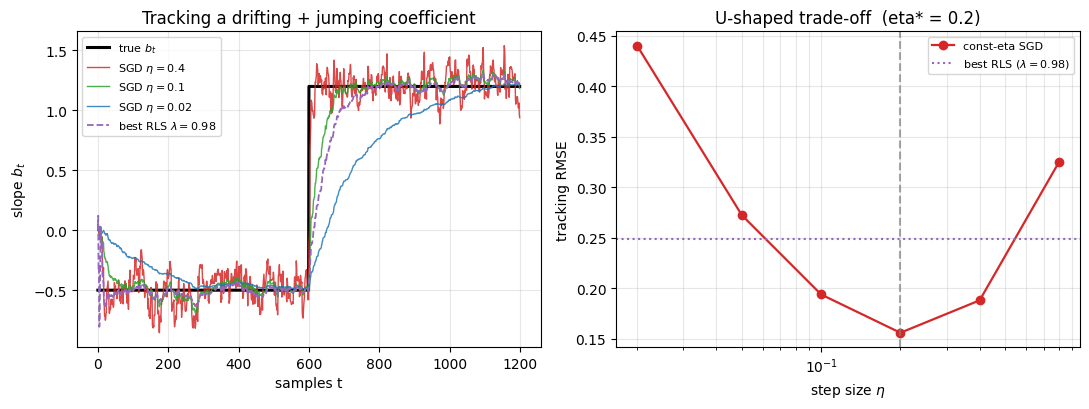

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ax[0].plot(t, b_star, color='k', lw=2.2, label=r'true $b_t$')
for e, c in zip([0.40, 0.10, 0.02], ['#d62728', '#2ca02c', '#1f77b4']):
    ax[0].plot(t, sgd_trajs[e][:, 1], color=c, lw=1.0, alpha=0.85, label=fr'SGD $\eta={e}$')
ax[0].plot(t, rls_traj[:, 1], color='#9467bd', lw=1.3, ls='--',
           label=fr'best RLS $\lambda={lam_star}$')
ax[0].set_xlabel('samples t'); ax[0].set_ylabel(r'slope $b_t$')
ax[0].set_title('Tracking a drifting + jumping coefficient')
ax[0].grid(True, alpha=0.3); ax[0].legend(fontsize=8)

ev = np.array(etas); rm = df['sgd_rmse'].values
ax[1].semilogx(ev, rm, 'o-', color='#d62728', lw=1.6, label='const-eta SGD')
ax[1].axvline(eta_star, ls='--', color='gray', alpha=0.7)
ax[1].axhline(rls_best, ls=':', color='#9467bd', lw=1.5,
              label=fr'best RLS ($\lambda={lam_star}$)')
ax[1].set_xlabel(r'step size $\eta$'); ax[1].set_ylabel('tracking RMSE')
ax[1].set_title(f'U-shaped trade-off  (eta* = {eta_star})')
ax[1].grid(True, which='both', alpha=0.3); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. 결과 해석

SGD $\eta$ 스윕 RMSE: $0.02{\to}0.44$, $0.05{\to}0.27$, $0.1{\to}0.19$, $\eta^\star{=}0.2{\to}\mathbf{0.156}$(최소), $0.4{\to}0.19$, $0.8{\to}0.32$ — 뚜렷한 **U자**. RLS 는 스윕에서 여러 $\lambda$ 가 **blow-up**(공분산 windup)했고, 안정 최적은 $\lambda^\star{=}0.98$ 로 RMSE $\mathbf{0.249}$.

1. **U자 상충의 재현**: 우측 곡선은 §14.6 의 $\lambda$ 스윕과 판박이다. $\eta$ 크면($N_{\text{eff}}$ 짧음) 점프를 빨리 따라가나 잡음 흡수로 RMSE↑, $\eta$ 작으면 매끄럽지만 램프·점프에 굼떠 편향으로 RMSE↑. 중간 $\eta^\star{=}0.2$ 에서 최소.
2. **급점프 반응**(좌): $t=600$ 직후 $\eta=0.40$(빨강)은 새 값에 빠르게 붙되 평소 요동이 크고, $\eta=0.02$(파랑)는 매끄럽지만 한참 뒤에 도달 — 망각인자 그림과 정확히 대응.
3. **$\eta\leftrightarrow\lambda$ 대응**: 표의 $N_{\text{eff}}\approx1/\eta$, $\lambda\approx1-1/N_{\text{eff}}$ 가 $\eta^\star{=}0.2$ 를 $\lambda\!\approx\!0.8$ 에 대응시킨다 — 두 손잡이가 같은 편향-분산 축임을 수치로 확인.
4. **best-vs-best & RLS 취약성**: 이 **저여기 스트림**에서 순수 망각-RLS 는 작은 $\lambda$ 에서 공분산 windup 으로 불안정(스윕 중 여러 개 blow-up)했고, 안정 최적조차 RMSE 0.249 로 **최적 SGD(0.156)보다 나빴다**. 즉 여기서는 등방 스텝의 SGD 가 **더 싸고($\mathcal O(p)$) 더 안정적이며 더 정확**했다. RLS 의 $P_t$ 정규화 이점은 입력이 조건 나쁠(상관 큰) 때 살아나며, 거의 백색인 이 입력에선 그 이점이 없고 windup 위험만 남는다.

> **결론**: 상수 학습률 SGD 는 유효기억 $N_{\text{eff}}\approx1/\eta$ 를 갖는 **망각 학습기**이고 $\eta$ 는 망각인자 $\lambda$ 와 같은 손잡이다. 저여기 비정상 스트림에서는 SGD 가 forgetting-RLS 보다 싸고 안정적이며 정확했다 — '수렴하지 않는' 상수 스텝이 오히려 무기가 된다.

**다음 Day 예고**: §14.7 로 SGD·미니배치·상수스텝 망각을 하나의 편향-분산 관점으로 묶었다. 다음은 **적응적 학습률**(AdaGrad/RMSProp류의 좌표별 스케일링)로 조건수/windup 문제를 완화하거나, 정규 교재 절 순서로 진도를 잇는다.